# Flow Matching from Scratch!

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup environment

In [2]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.0 MB/s eta 0:00:00


In [3]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Training a Single-step Denoising UNet


## Implementing Simple and Composed Ops

In [4]:
import torch

class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(x)
        x = self.act(x)
        return x


class Unflatten(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, out_size: int = 7):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=out_size,
                stride=out_size,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

## Implementing Unconditional UNet

In [5]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        D = num_hiddens

        #Encoder
        self.enc1 = ConvBlock(in_channels, D)
        self.enc2 = DownBlock(D, D)
        self.enc3 = DownBlock(D, 2 * D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D, 2 * D, out_size=7)

        self.up1 = UpBlock(4 * D, 2 * D)          # (4D → 2D), 7×7→14×14
        self.up2 = UpBlock(4 * D, D)              # (4D → D), 14×14→28×28
        self.up3 = UpBlock(2*D, D)
        self.dec_final = ConvBlock(2 * D, D)      # final ConvBlock after concat

        self.output = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # ---- Encoder ----
        x1 = self.enc1(x)      # [B, D, 28, 28]
        x2 = self.enc2(x1)     # [B, D, 14, 14]
        x3 = self.enc3(x2)     # [B, 2D, 7, 7]

        b = self.flatten(x3)   # [B, 2D, 1, 1]
        b = self.unflatten(b)  # [B, 2D, 7, 7]

        # ---- Decoder ----
        y1 = torch.cat([b, x3], dim=1)  # concat skip (→ 4D)

        y2 = self.up2(y1)      # [B, 2D, 14, 14]
        y2 = torch.cat([y2, x2], dim=1)  # concat skip (→ 2D)

        y3 = self.up3(y2)      # [B, D, 28, 28]
        y3 = torch.cat([y3, x1], dim=1)  # concat skip

        y4 = self.dec_final(y3)  # [B, D, 28, 28]

        return self.output(y4)

## Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.34MB/s]
Epoch 5/5: 100%|██████████| 235/235 [00:15<00:00, 15.51it/s, loss=8.4520e-03]


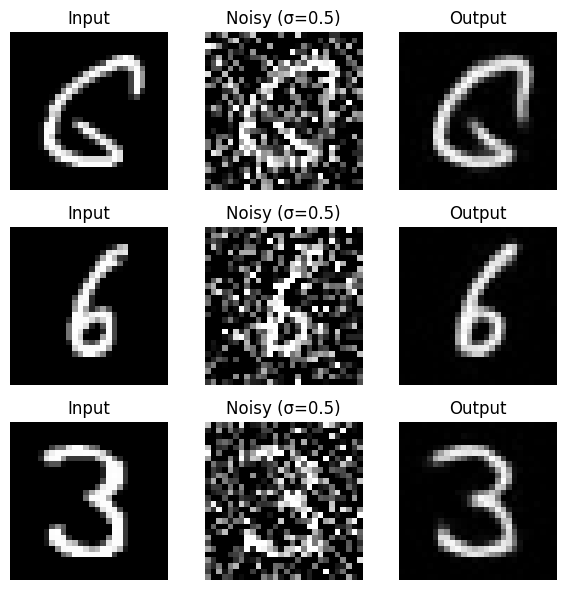

In [6]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

# Model
model = UnconditionalUNet(in_channels=1, num_hiddens=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
epochs = 5
sigma = 0.5

for epoch in range(epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for clean, _ in pbar:
        clean = clean.to(device)

        # add Gaussian noise each iteration
        noisy = torch.clamp(clean + sigma * torch.randn_like(clean), 0.0, 1.0)

        denoised = model(noisy)
        loss = F.mse_loss(denoised, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.set_postfix({"loss": f"{loss.item():.4e}"})



# --- switch model to evaluation mode ---
model.eval()

# --- load test set ---
test_data = MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_data, batch_size=8, shuffle=True)

# --- get one batch of test images ---
clean_imgs, _ = next(iter(test_loader))
clean_imgs = clean_imgs.to(device)

# --- add Gaussian noise ---
sigma = 0.5
noisy_imgs = torch.clamp(clean_imgs + sigma * torch.randn_like(clean_imgs), 0.0, 1.0)

# --- denoise using trained UNet ---
with torch.no_grad():
    denoised_imgs = model(noisy_imgs)

# --- helper: visualize ---
def show_images(clean, noisy, denoised, num=5):
    clean = clean.cpu()
    noisy = noisy.cpu()
    denoised = denoised.cpu()
    fig, axes = plt.subplots(num, 3, figsize=(6, num * 2))
    for i in range(num):
        axes[i, 0].imshow(clean[i][0], cmap="gray", vmin=0, vmax=1)
        axes[i, 0].set_title("Input")
        axes[i, 1].imshow(noisy[i][0], cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Noisy (σ=0.5)")
        axes[i, 2].imshow(denoised[i][0], cmap="gray", vmin=0, vmax=1)
        axes[i, 2].set_title("Output")
        for j in range(3):
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

# --- visualize results ---
show_images(clean_imgs, noisy_imgs, denoised_imgs, num=3)


# Part 2: Flow Matching

## Implementing a Time-conditioned UNet

In [7]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        D = num_hiddens

        #Encoder
        self.enc1 = ConvBlock(in_channels, D)
        self.enc2 = DownBlock(D, D)
        self.enc3 = DownBlock(D, 2 * D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D, 2 * D, out_size=7)

        self.up1 = UpBlock(4 * D, 2 * D)          # (4D → 2D), 7×7→14×14
        self.up2 = UpBlock(4 * D, D)              # (4D → D), 14×14→28×28
        self.up3 = UpBlock(2*D, D)
        self.dec_final = ConvBlock(2 * D, D)      # final ConvBlock after concat

        self.fc1 = FCBlock(1, 2 * D)
        self.fc2 = FCBlock(1, D)

        self.output = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)


    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
         # ---- Encoder ----
        x1 = self.enc1(x)      # [B, D, 28, 28]
        x2 = self.enc2(x1)     # [B, D, 14, 14]
        x3 = self.enc3(x2)     # [B, 2D, 7, 7]

        b = self.flatten(x3)   # [B, 2D, 1, 1]
        b = self.unflatten(b)  # [B, 2D, 7, 7]

        t_emb = self.fc1(t.unsqueeze(-1))
        t_emb = t_emb[:, :, None, None]

        b = b + t_emb

        # ---- Decoder ----
        y1 = torch.cat([b, x3], dim=1)  # concat skip (→ 4D)

        y2 = self.up2(y1)      # [B, D, 14, 14]

        t_emb2 = self.fc2(t.unsqueeze(-1))  # [B, D]
        t_emb2 = t_emb2[:, :, None, None]
        y2 = y2 + t_emb2

        y2 = torch.cat([y2, x2], dim=1)  # concat skip (→ 2D)


        y3 = self.up3(y2)      # [B, D, 28, 28]
        y3 = torch.cat([y3, x1], dim=1)  # concat skip

        y4 = self.dec_final(y3)  # [B, D, 28, 28]

        return self.output(y4)

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [8]:
def fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # YOUR CODE HERE.
    B, C, H, W = x_1.shape
    device = x_1.device

    x_0 = torch.randn_like(x_1)
    t = torch.rand(B, device=device)
    x_t = (1 - t)[:, None, None, None] * x_0 + t[:, None, None, None] * x_1
    u_true = x_1 - x_0
    u_pred = unet(x_t, t)
    loss = torch.mean((u_true - u_pred) ** 2)

    return loss

In [17]:
@torch.inference_mode()
def fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # YOUR CODE HERE.

    device = next(unet.parameters()).device
    H, W = img_wh

    x_t = torch.randn(1, 1, H, W, device=device)
    t_values = torch.linspace(0.0, 1.0, num_ts, device=device)

    for i in range(num_ts - 1):
        t = t_values[i].repeat(1)
        dt = t_values[i + 1] - t_values[i]
        u_pred = unet(x_t, t)
        x_t = x_t + dt * u_pred

    return x_t


In [18]:
class FlowMatching(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Training Flow Matching

Epoch 1/20: 100%|██████████| 938/938 [00:17<00:00, 54.36it/s, loss=1.1491e-01]


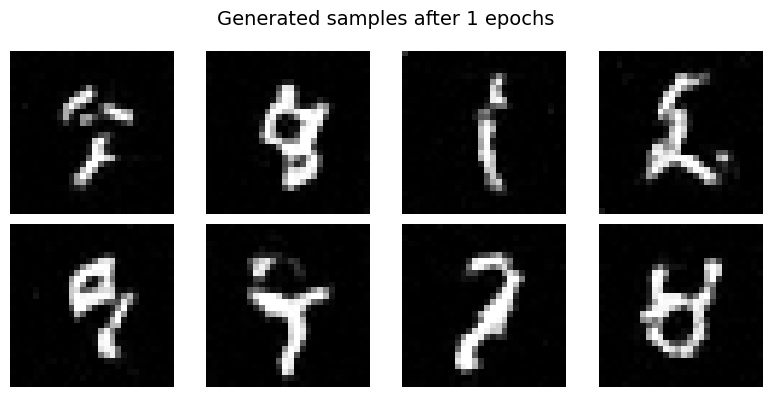

Epoch 5/20: 100%|██████████| 938/938 [00:17<00:00, 54.78it/s, loss=8.3632e-02]


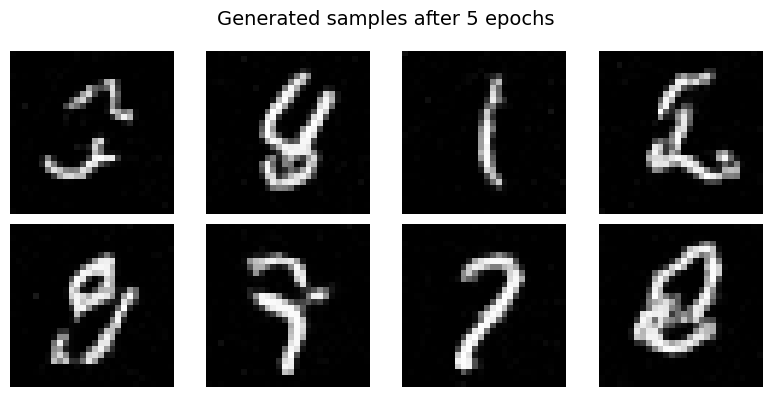

Epoch 10/20: 100%|██████████| 938/938 [00:17<00:00, 54.60it/s, loss=9.3260e-02]


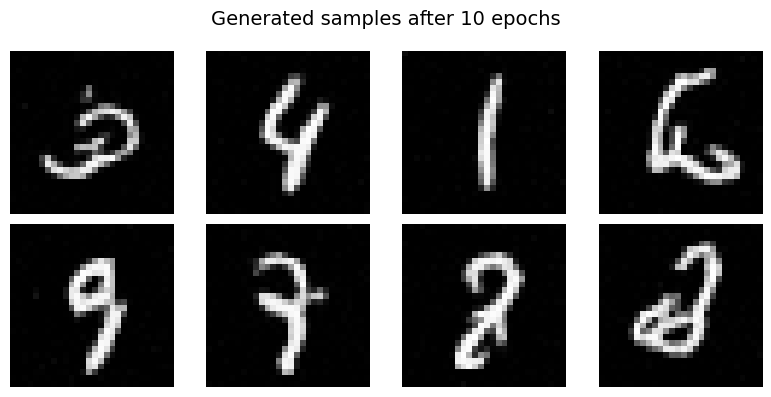

Epoch 15/20: 100%|██████████| 938/938 [00:17<00:00, 53.85it/s, loss=8.7767e-02]


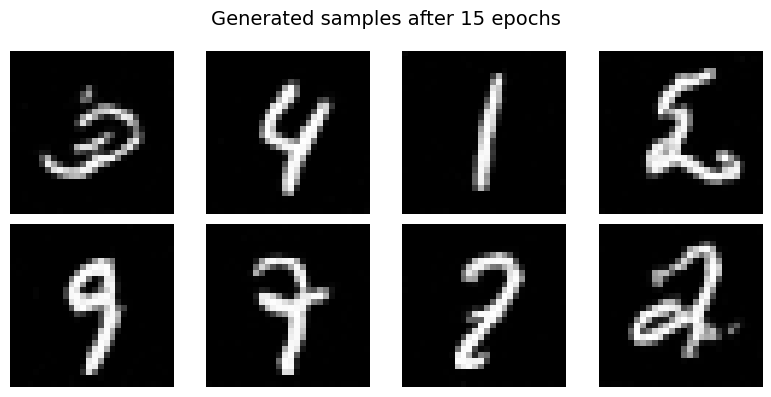

Epoch 20/20: 100%|██████████| 938/938 [00:17<00:00, 53.57it/s, loss=8.3092e-02]


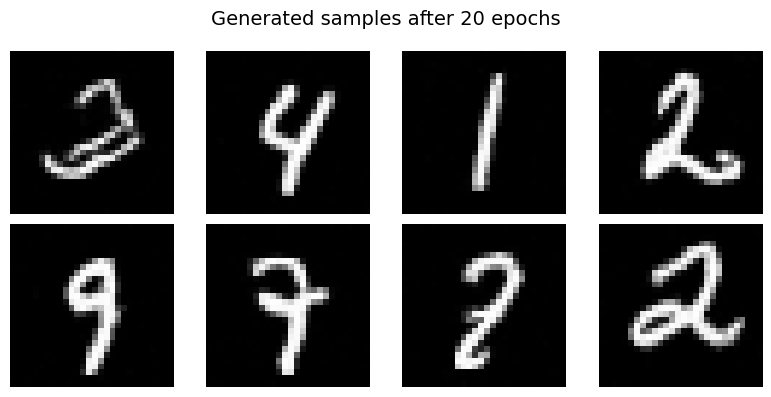

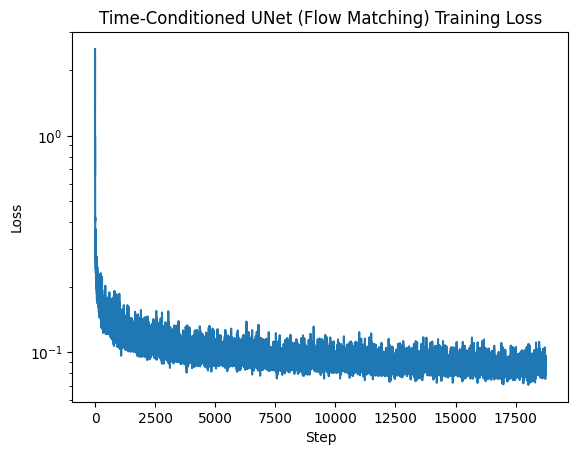

In [21]:
import torch
from tqdm import tqdm
import math
import matplotlib.pyplot as plt

# Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = TimeConditionalUNet(in_channels=1, num_hiddens=64).to(device)
model = FlowMatching(unet, num_ts=10, img_hw=(28, 28)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1.0 / 20))

# --- training loop ---
epochs = 20
losses = []

for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for clean, _ in pbar:
        clean = clean.to(device)

        # forward pass through Flow Matching model
        loss = model(clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4e}"})

    scheduler.step()
    # --- inside the training loop, right after scheduler.step() ---
    if (epoch + 1) in [1, 5, 10, 15, 20]:
        model.eval()
        n_samples = 8
        samples = []
        torch.manual_seed(0)
        with torch.inference_mode():
          for i in range(n_samples):
            x_sample = model.sample(img_wh=(28, 28))
            samples.append(x_sample.squeeze().cpu())

        cols = 4
        rows = math.ceil(n_samples / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

        for i, ax in enumerate(axes.flat):
            if i < n_samples:
                ax.imshow(samples[i], cmap="gray", vmin=0, vmax=1)
                ax.axis("off")
            else:
                ax.remove()

        plt.suptitle(f"Generated samples after {epoch+1} epochs", fontsize=14)
        plt.tight_layout()
        plt.show()


# --- plot loss curve ---
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Time-Conditioned UNet (Flow Matching) Training Loss")
plt.show()


### Implementing class-conditioned UNet

In [54]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)




class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        D = num_hiddens
        self.num_classes = num_classes

        #Encoder
        self.enc1 = ConvBlock(in_channels, D)
        self.enc2 = DownBlock(D, D)
        self.enc3 = DownBlock(D, 2 * D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D, 2 * D, out_size=7)

        self.up1 = UpBlock(4 * D, 2 * D)          # (4D → 2D), 7×7→14×14
        self.up2 = UpBlock(4 * D, D)              # (4D → D), 14×14→28×28
        self.up3 = UpBlock(2 * D, D)
        self.dec_final = ConvBlock(2 * D, D)      # final ConvBlock after concat

        self.fc1_t = FCBlock(1, 2 * D)
        self.fc2_t = FCBlock(1, D)

        self.fc1_c = FCBlock(num_classes, 2 * D)
        self.fc2_c = FCBlock(num_classes, D)

        self.output = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()

        if mask is not None:
          c_onehot = c_onehot * mask

        x1 = self.enc1(x)      # [B, D, 28, 28]
        x2 = self.enc2(x1)     # [B, D, 14, 14]
        x3 = self.enc3(x2)     # [B, 2D, 7, 7]

        b = self.flatten(x3)   # [B, 2D, 1, 1]
        b = self.unflatten(b)  # [B, 2D, 7, 7]

        t_emb = self.fc1_t(t.unsqueeze(-1))
        c1 = self.fc1_c(c_onehot)[:, :, None, None]
        t_emb = t_emb[:, :, None, None]

        b = b + t_emb + c1

        # ---- Decoder ----
        y1 = torch.cat([b, x3], dim=1)  # concat skip (→ 4D)

        y2 = self.up2(y1)      # [B, D, 14, 14]

        t_emb2 = self.fc2_t(t.unsqueeze(-1))  # [B, D]
        c2 = self.fc2_c(c_onehot)[:, :, None, None]
        t_emb2 = t_emb2[:, :, None, None]
        y2 = y2 + t_emb2 + c2

        y2 = torch.cat([y2, x2], dim=1)  # concat skip (→ 2D)


        y3 = self.up3(y2)      # [B, D, 28, 28]
        y3 = torch.cat([y3, x1], dim=1)  # concat skip

        y4 = self.dec_final(y3)  # [B, D, 28, 28]

        return self.output(y4)

In [55]:
def fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # YOUR CODE HERE.
    B, C, H, W = x_1.shape
    device = x_1.device

    x_0 = torch.randn_like(x_1)
    t = torch.rand(B, device=device)
    x_t = (1 - t)[:, None, None, None] * x_0 + t[:, None, None, None] * x_1
    u_true = x_1 - x_0
    mask = (torch.rand(B, 1, device=device) > p_uncond).float()
    u_pred = unet(x_t, c, t, mask)
    loss = torch.mean((u_true - u_pred) ** 2)

    return loss

In [60]:
@torch.inference_mode()
def fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # YOUR CODE HERE.
    torch.manual_seed(seed)
    device = next(unet.parameters()).device
    B = c.size(0)
    H, W = img_wh

    x_t = torch.randn(B, 1, H, W, device=device)
    t_values = torch.linspace(0.0, 1.0, num_ts, device=device)

    c_uncond = torch.zeros_like(c)

    for i in range(num_ts - 1):
        t = t_values[i].repeat(B)
        dt = t_values[i + 1] - t_values[i]
        u_cond = unet(x_t, c, t)
        u_uncond = unet(x_t, c_uncond, t)
        u_pred = u_uncond + guidance_scale * (u_cond - u_uncond)
        x_t = x_t + dt * u_pred

    x_t = x_t.clamp(0, 1)
    return x_t

In [61]:
class FlowMatching(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.img_hw = img_hw

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

Epoch 1/20: 100%|██████████| 938/938 [00:18<00:00, 50.93it/s, loss=1.2498e-01]


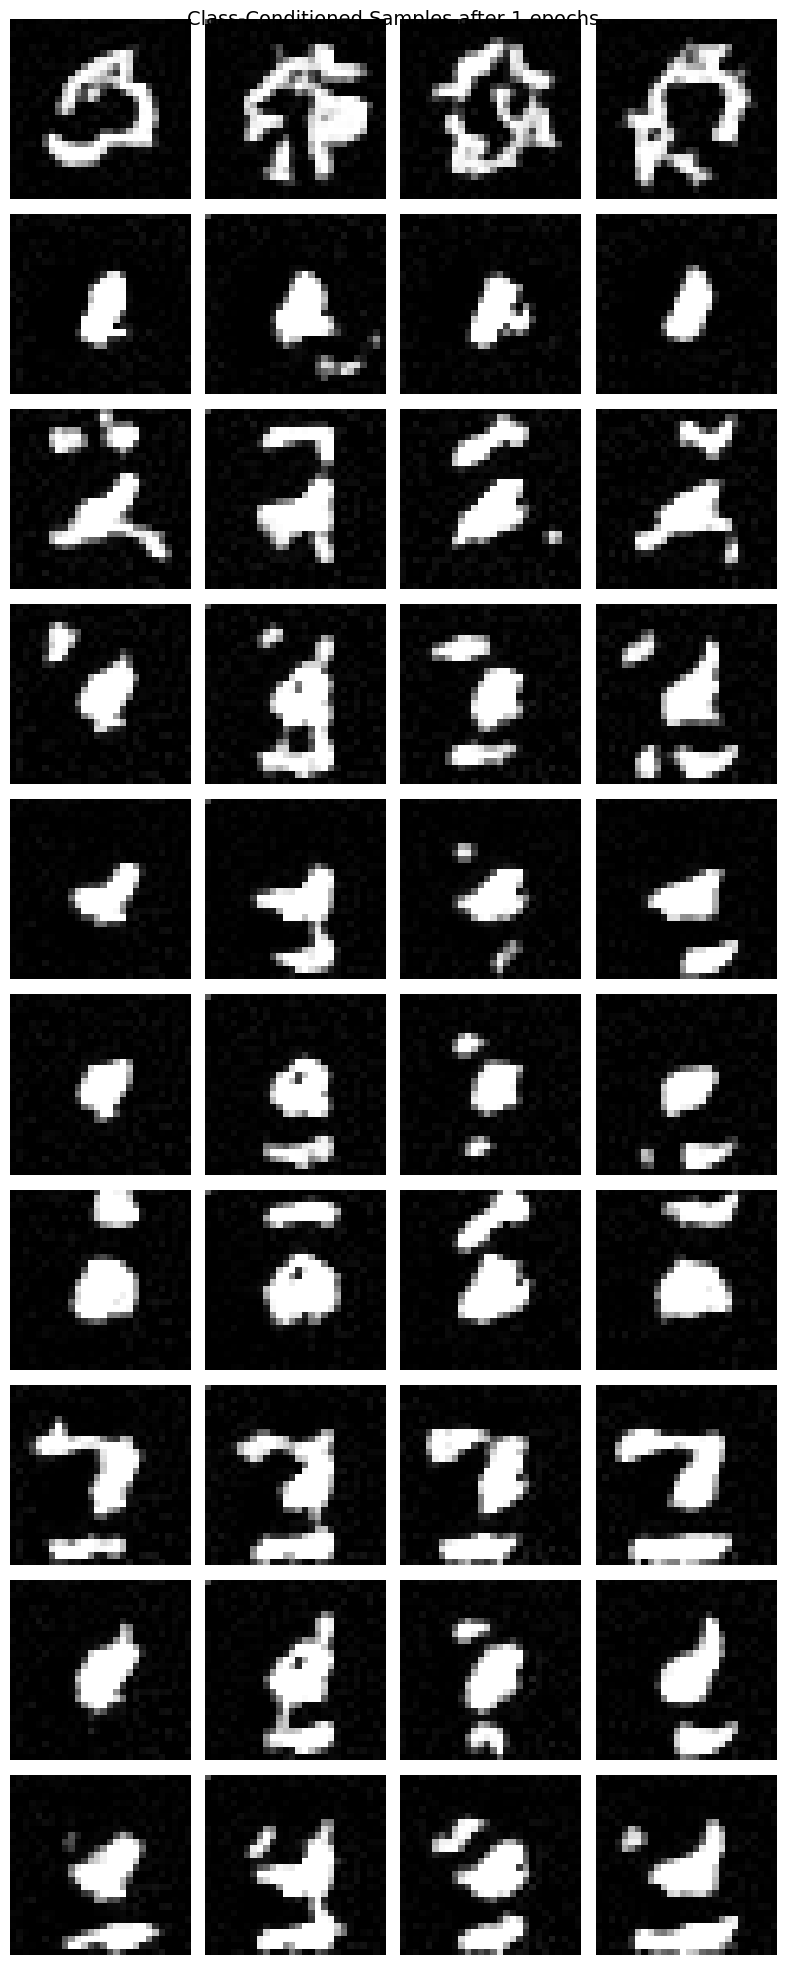

Epoch 5/20: 100%|██████████| 938/938 [00:18<00:00, 50.22it/s, loss=9.3043e-02]


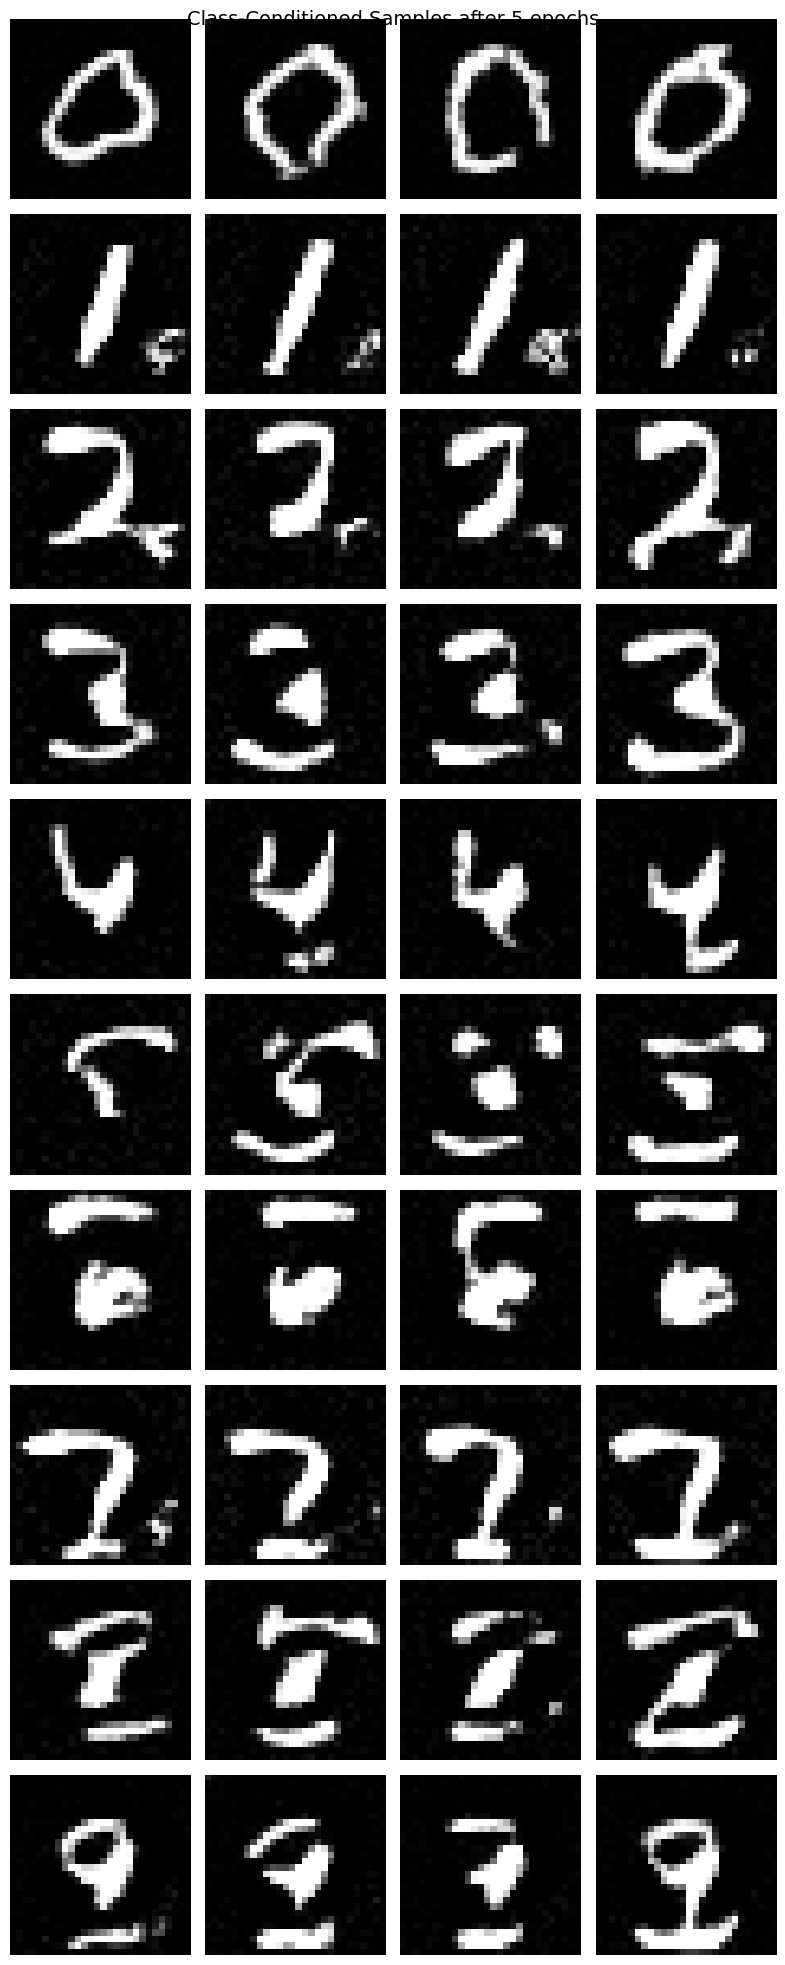

Epoch 10/20: 100%|██████████| 938/938 [00:18<00:00, 49.74it/s, loss=8.1074e-02]


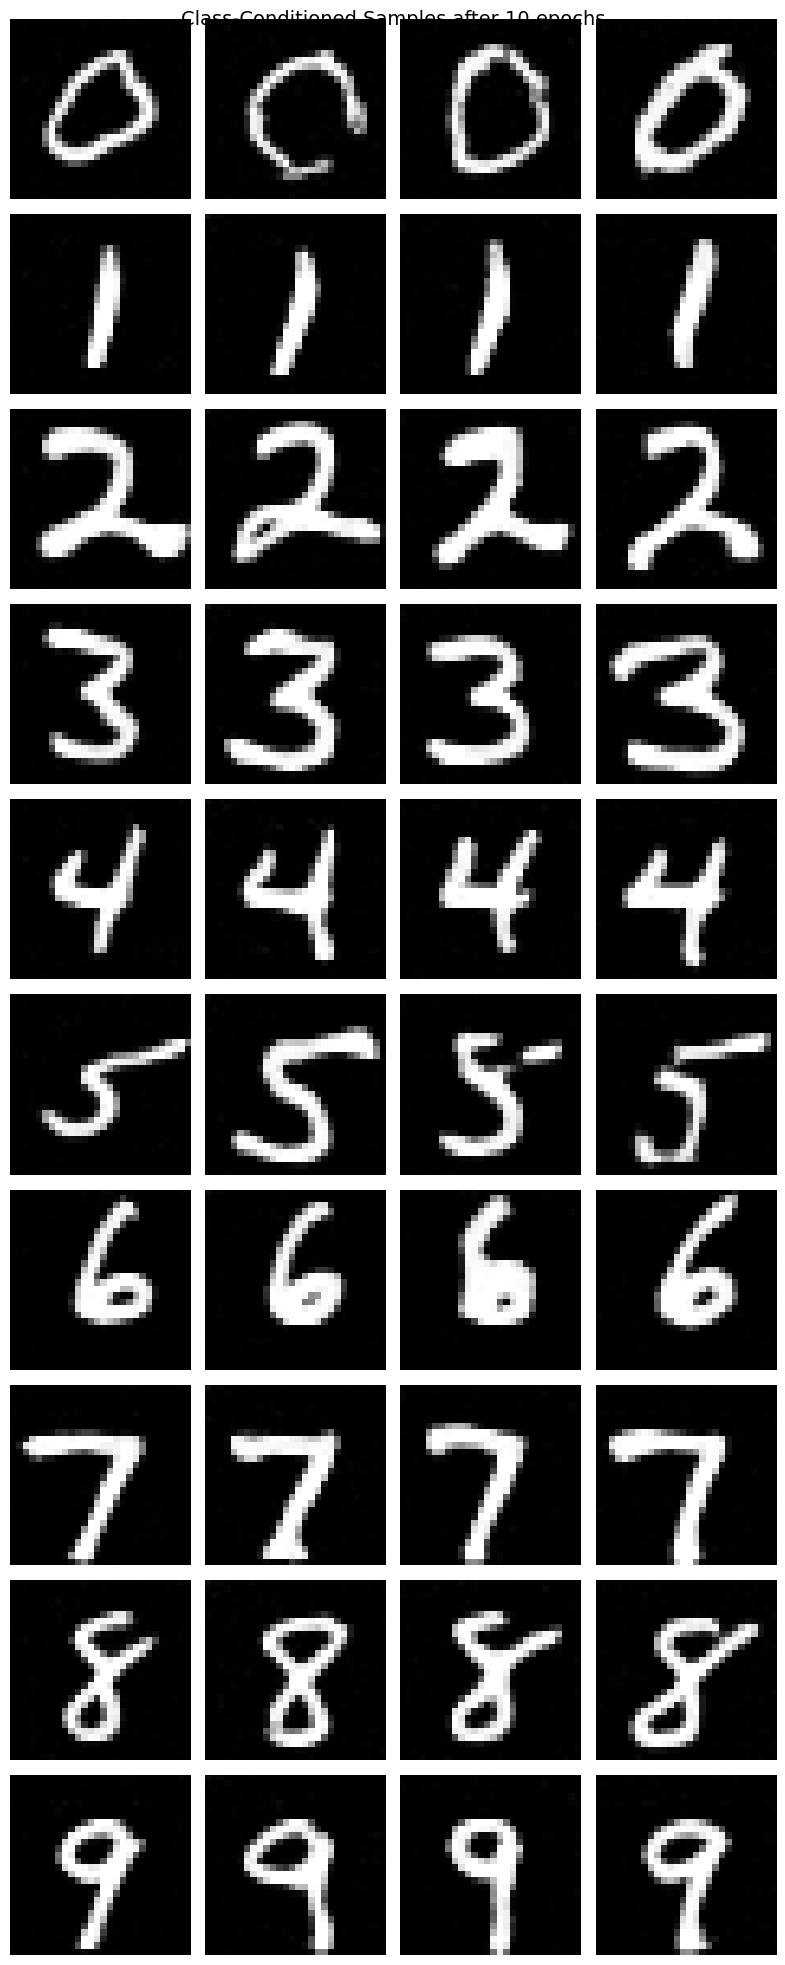

Epoch 15/20: 100%|██████████| 938/938 [00:19<00:00, 49.06it/s, loss=7.6390e-02]


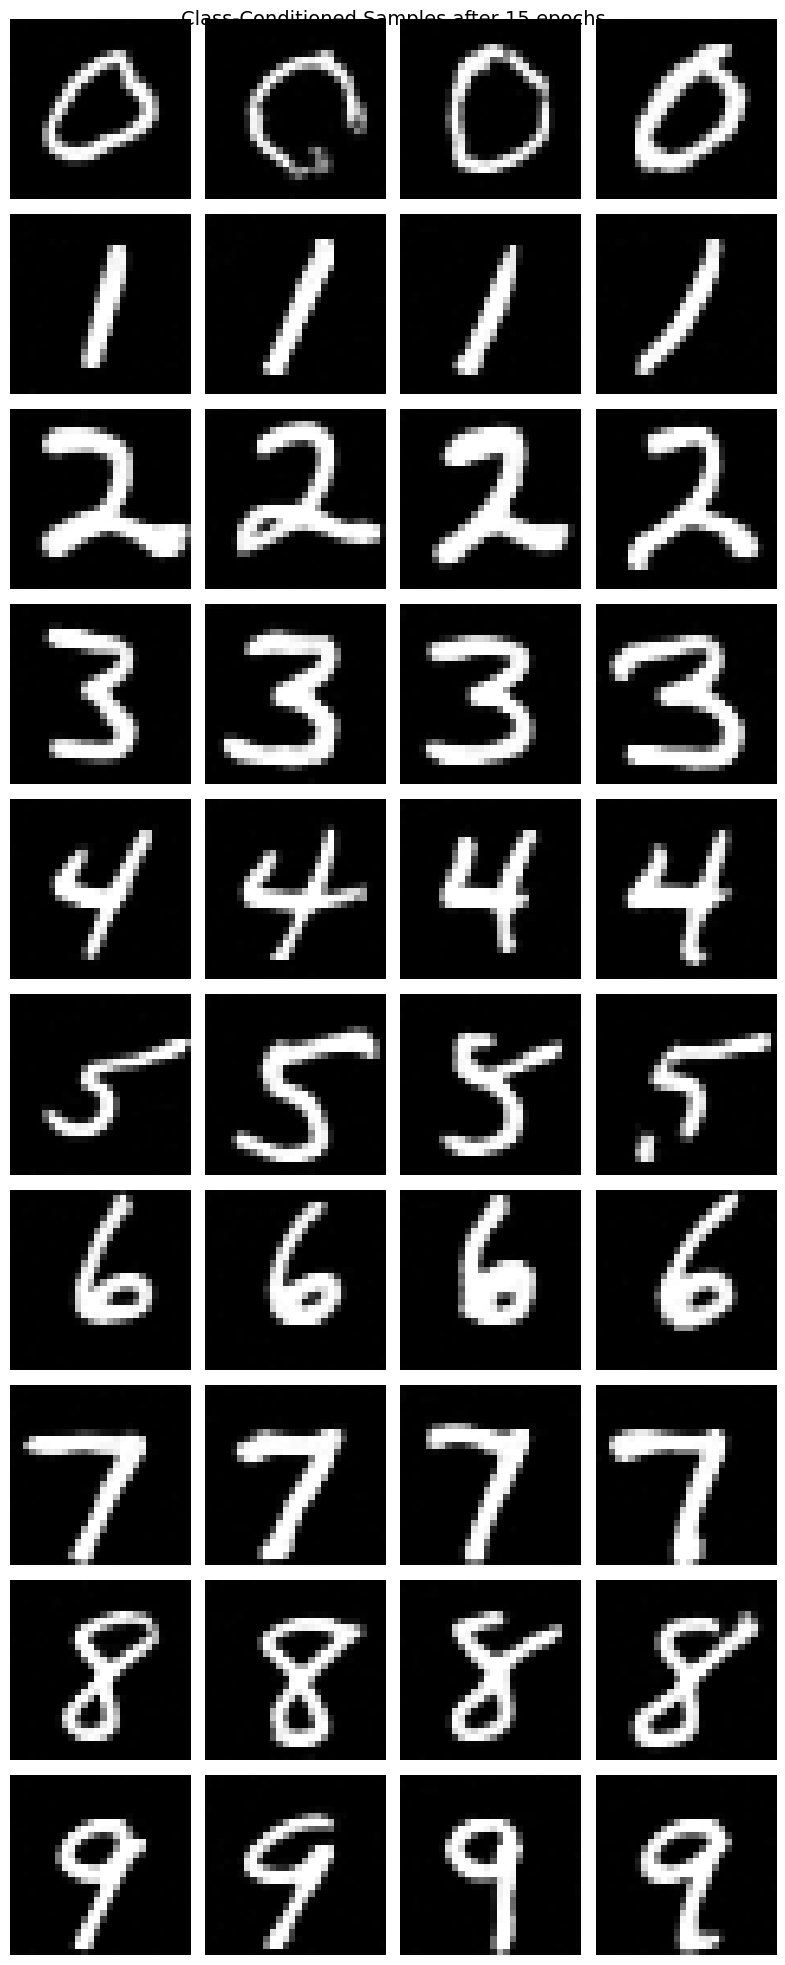

Epoch 20/20: 100%|██████████| 938/938 [00:19<00:00, 49.17it/s, loss=7.4407e-02]


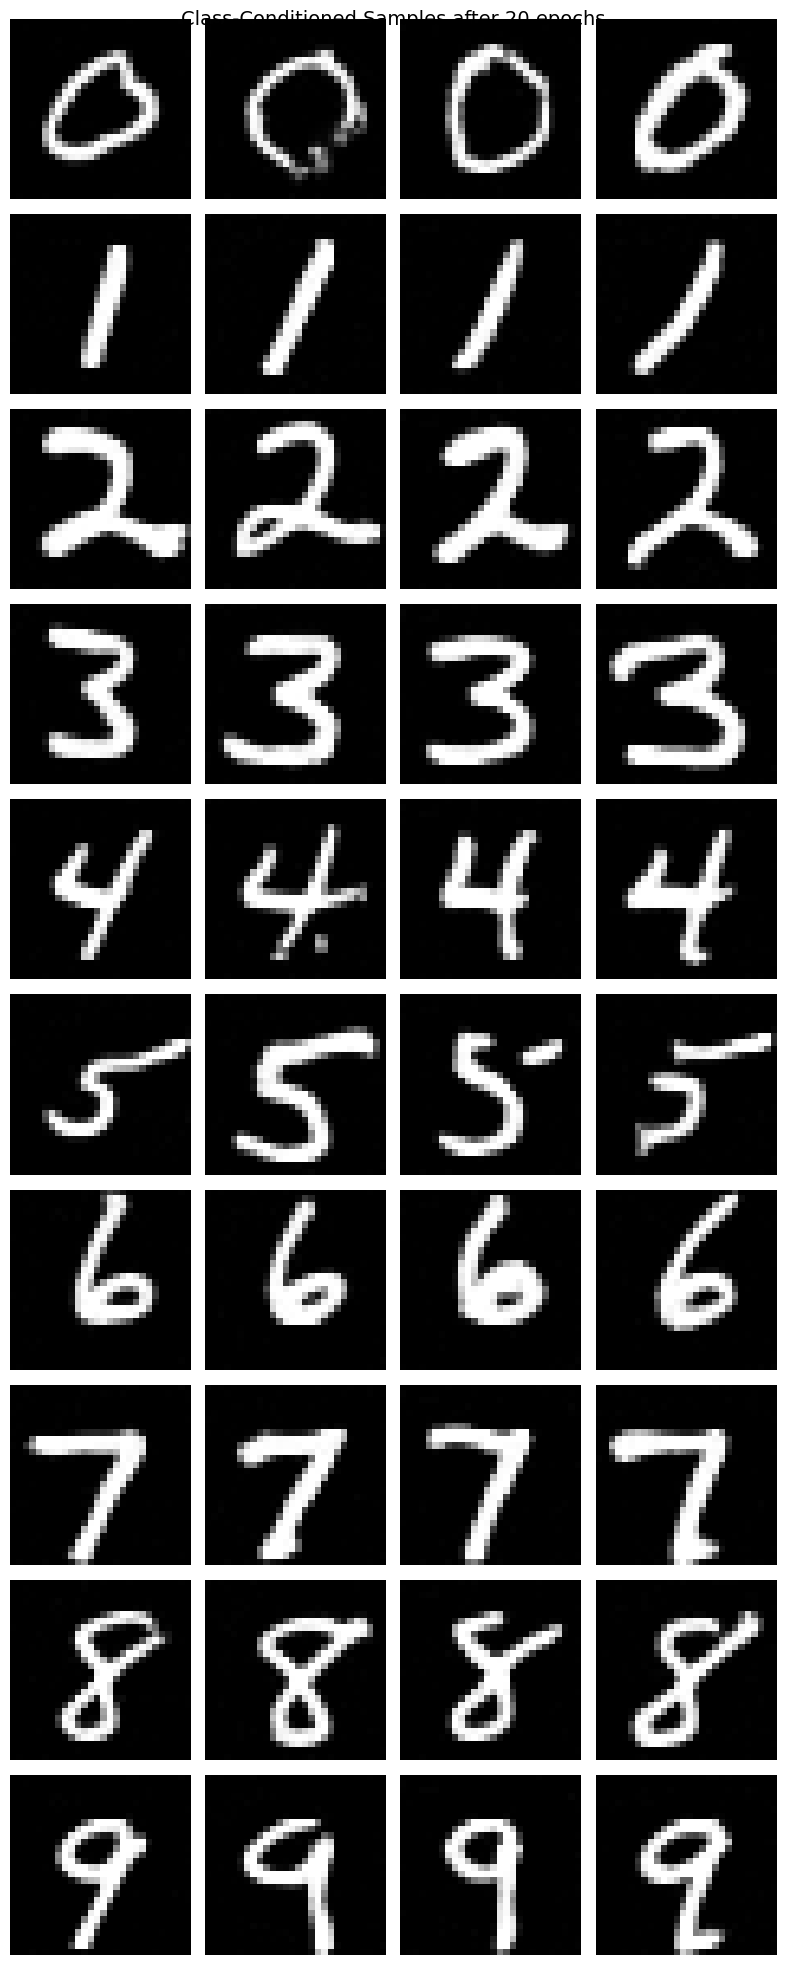

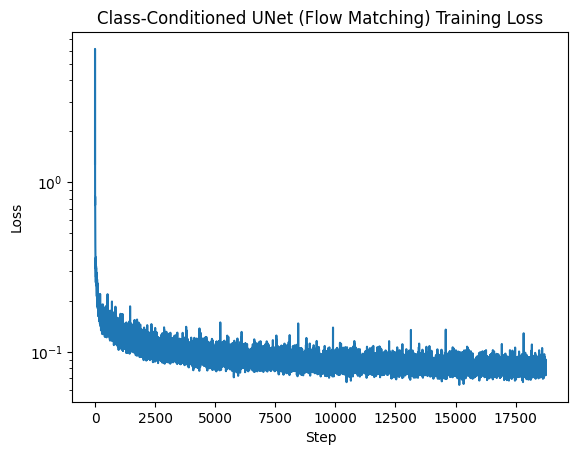

In [62]:
import torch
from tqdm import tqdm
import math
import matplotlib.pyplot as plt

# Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet =  ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=64).to(device)
model = FlowMatching(unet, num_ts=10, img_hw=(28, 28) , p_uncond=0.1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1.0 / 20))


# --- Training Loop ---
epochs = 20
losses = []

for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for clean, labels in pbar:
        clean, labels = clean.to(device), labels.to(device)

        # forward pass
        loss = model(clean, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4e}"})

    scheduler.step()

    # --- Generate samples at specific epochs ---
    if (epoch + 1) in [1, 5, 10, 15, 20]:
        model.eval()
        torch.manual_seed(0)

        # 10 digits × 4 samples each = 40 total
        n_digits, n_per_class = 10, 4
        all_samples = []

        with torch.inference_mode():
            for digit in range(n_digits):
                c = torch.full((n_per_class,), digit, dtype=torch.long, device=device)
                samples = model.sample(c, img_wh=(28, 28), guidance_scale=5.0, seed=0)
                all_samples.append(samples.cpu())

        all_samples = torch.cat(all_samples, dim=0)

        # --- Plot results ---
        cols, rows = n_per_class, n_digits
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

        for i, ax in enumerate(axes.flat):
            ax.imshow(all_samples[i, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")

        plt.suptitle(f"Class-Conditioned Samples after {epoch+1} epochs", fontsize=14)
        plt.tight_layout()
        plt.show()

# --- Plot loss curve ---
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Class-Conditioned UNet (Flow Matching) Training Loss")
plt.show()
